## Bradford Air Quality Analysis (01/11/2024 - 17/01/2025)

Analysis of winter PM2.5 and PM10 air quality data across Bradford monitoring sites, developed for HDRC and councillor briefing

### Configuration

1. **Installing required packages:** 

   This ensures the Python environment has the exact libraries needed to run the analysis.

In [1]:
# Install required packages

import sys
#!{sys.executable} -m pip install -r ../requirements.txt

2. **Import necessary libraries:**

    This loads the tools needed for:
    - file handling + patterns (os, re) 
    - numeric processing (numpy)
    - tabular data analysis (pandas)
    - data visualisation (matplotlib)
    - path creation (Path)

In [2]:
# Import the necessary libraries
from __future__ import annotations

import os
import argparse
import re
from pathlib import Path
from typing import Optional, Tuple, List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio

3. **Path allocation:**

    This defines standard folders used in the project for:
    - raw input data (`data/raw`)
    - processed data (`data/processed`
    - external data (`data/external`)
    - output directory (`outputs`)

In [3]:
# Create directory structure if it does not already exist
raw_data = Path("../data/raw")
pro_data = Path("../data/processed")
ext_data = Path("../data/external")
out_dir = Path("../outputs")

for path in [raw_data, pro_data, ext_data, out_dir]:
    path.mkdir(parents=True, exist_ok=True)

4. **Reference thresholds:**

    The following external reference points are used for context only:

    - **PM2.5 (24-hour mean): 15 µg/m³**  
    WHO Global Air Quality Guidelines (2021). 
    - **PM10 (24-hour mean): 50 µg/m³**  
      UK Air Quality Objective used in Local Air Quality Management (LAQM).  

### Data preprocessing

1. **Load and structure data:** 
    - The raw Excel file uses merged site headers.
    - It loads the data and applies clear column names to enable reliable processing.
    - Also fix the 24:00 o'clock to the next day 00:00 o'clock
    - Drop the invalid rows - especially the summary statistics at the base of the sheet

In [4]:
# Load the sheet
input_file = raw_data / "Multi Station Report 01_11_2024.xlsx"
raw = pd.read_excel(input_file)

# On physical inspection, we only need columns (A to G)
raw = raw.iloc[:, :7].copy()

# Rename columns to a stable schema
raw.columns = [
    "datetime",
    "keighley_pm10", "keighley_pm25",
    "tong_pm10",     "tong_pm25",
    "treadwell_pm10","treadwell_pm25"
]

# Fix 24:00 o'clock, as it is not recognisable as an ideal time 
dt_raw = raw["datetime"].astype(str).str.strip()
mask_24 = dt_raw.str.contains(r"\b24:00\b", na=False)

# Replace 24:00 with 00:00
dt_fixed = dt_raw.copy()
dt_fixed.loc[mask_24] = dt_fixed.loc[mask_24].str.replace("24:00", "00:00", regex=False)

# Parse datetime - UK day-first
dt_parsed = pd.to_datetime(dt_fixed, errors="coerce", dayfirst=True)

# Add one day to rows that originally had 24:00
dt_parsed.loc[mask_24] = dt_parsed.loc[mask_24] + pd.Timedelta(days=1)

raw["datetime"] = dt_parsed

# Now drop invalid rows - especially the summary statistics at the base
raw = raw.dropna(subset=["datetime"]).reset_index(drop=True)

# Coerce numeric pollution columns
for c in raw.columns[1:]:
    raw[c] = pd.to_numeric(raw[c], errors="coerce")

# A quick peek
display(raw.head())
print("Shape:", raw.shape)

/var/folders/l0/yncq7vg114z8zt1w1r4thfwc0000gn/T/ipykernel_38818/3455288.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt_parsed = pd.to_datetime(dt_fixed, errors="coerce", dayfirst=True)


,datetime,keighley_pm10,keighley_pm25,tong_pm10,tong_pm25,treadwell_pm10,treadwell_pm25
0,2024-11-01 01:00:00,6.2,5.2,10.2,5.8,NaN,NaN
1,2024-11-01 02:00:00,1.0,-0.9,2.1,-1.3,NaN,NaN
2,2024-11-01 03:00:00,6.1,4.6,7.3,4.3,NaN,NaN
3,2024-11-01 04:00:00,5.8,4.2,11.6,7.8,NaN,NaN
4,2024-11-01 05:00:00,2.8,1.0,2.4,-1.4,NaN,NaN


Shape: (1848, 7)


2. **Reshape to tidy format:** 
    - The data is reshaped into a tidy format with one row per site per timestamp  
(`datetime | site | pm10 | pm25`) to support analysis and comparison.

In [5]:
# Reshape to long tidy format: datetime | date | hour | week | site | pm10 | pm25
site_map = {
    "Bradford Keighley": ("keighley_pm10", "keighley_pm25"),
    "Bradford Tong Street": ("tong_pm10", "tong_pm25"),
    "Bradford Treadwell Mills": ("treadwell_pm10", "treadwell_pm25"),
}

frames = []
for site, (pm10_col, pm25_col) in site_map.items():
    tmp = raw[["datetime", pm10_col, pm25_col]].copy()
    tmp = tmp.rename(columns={pm10_col: "pm10", pm25_col: "pm25"})
    tmp["site"] = site
    frames.append(tmp)

df = pd.concat(frames, ignore_index=True)

# Time features derived strictly from datetime
df = df.assign(
    date=lambda x: x["datetime"].dt.normalize(),   # midnight of the same day
    hour=lambda x: x["datetime"].dt.hour,
    week=lambda x: x["datetime"].dt.to_period("W-MON")  # ISO-style week (Mon–Sun)
)

# Explicit column order
df = df[["datetime", "date", "hour", "week", "site", "pm10", "pm25"]]
df = df.sort_values(["site", "datetime"]).reset_index(drop=True)

display(df.head())
print("Sites:", df["site"].unique())
print("Datetime range:", df["datetime"].min(), "to", df["datetime"].max())

,datetime,date,hour,week,site,pm10,pm25
0,2024-11-01 01:00:00,2024-11-01,1,2024-10-29/2024-11-04,Bradford Keighley,6.2,5.2
1,2024-11-01 02:00:00,2024-11-01,2,2024-10-29/2024-11-04,Bradford Keighley,1.0,-0.9
2,2024-11-01 03:00:00,2024-11-01,3,2024-10-29/2024-11-04,Bradford Keighley,6.1,4.6
3,2024-11-01 04:00:00,2024-11-01,4,2024-10-29/2024-11-04,Bradford Keighley,5.8,4.2
4,2024-11-01 05:00:00,2024-11-01,5,2024-10-29/2024-11-04,Bradford Keighley,2.8,1.0


Sites: ['Bradford Keighley' 'Bradford Tong Street' 'Bradford Treadwell Mills']
Datetime range: 2024-11-01 01:00:00 to 2025-01-17 00:00:00


In [6]:
# Data Structure
df.shape

(5544, 7)

### Quality assurance checks

1. **Commissioning window and reporting hours:** 
    - Compute commissioning window and reporting hours for a given pollutant.
    - Commissioning is defined as the first to last non-missing observation.

In [7]:
# Commissioned window per site and pollutant
def commissioning_by_pollutant(df: pd.DataFrame, pollutant: str) -> pd.DataFrame:
    return (
        df.dropna(subset=[pollutant])
          .groupby("site", as_index=False)
          .agg(
              commissioned_from=("datetime", "min"),
              commissioned_to=("datetime", "max"),
              reporting_hours=("datetime", "count"),
          )
          .assign(pollutant=pollutant.upper())
    )

# Run separately for each pollutant
commissioning_pm10 = commissioning_by_pollutant(df, "pm10")
commissioning_pm25 = commissioning_by_pollutant(df, "pm25")

# Combine results
commissioning = pd.concat(
    [commissioning_pm10, commissioning_pm25],
    ignore_index=True
)

# Order by site first, then pollutant
commissioning = (
    commissioning[
        ["site", "pollutant", "commissioned_from", "commissioned_to", "reporting_hours"]
    ]
    .sort_values(["site", "pollutant"])
    .reset_index(drop=True)
)

display(commissioning)

,site,pollutant,commissioned_from,commissioned_to,reporting_hours
0,Bradford Keighley,PM10,2024-11-01 01:00:00,2025-01-17 00:00:00,1793
1,Bradford Keighley,PM25,2024-11-01 01:00:00,2025-01-17 00:00:00,1802
2,Bradford Tong Street,PM10,2024-11-01 01:00:00,2025-01-03 10:00:00,1466
3,Bradford Tong Street,PM25,2024-11-01 01:00:00,2025-01-03 10:00:00,1438
4,Bradford Treadwell Mills,PM10,2024-12-21 01:00:00,2025-01-17 00:00:00,648
5,Bradford Treadwell Mills,PM25,2024-12-21 01:00:00,2025-01-17 00:00:00,648


2. **Expected vs observed within commissioned window:** 
    - For each site, compute expected hours in the pollutant's commissioned window,
    observed hours (non-missing), downtime and uptime %.

In [8]:
# Uptime per site × pollutant (expected vs observed within commissioned window)
def uptime_by_pollutant(df: pd.DataFrame, commissioning_tbl: pd.DataFrame, pollutant: str) -> pd.DataFrame:
    pol = pollutant.lower()
    pol_label = pollutant.upper()

    # Commissioning window for this pollutant
    cw = (
        commissioning_tbl[commissioning_tbl["pollutant"] == pol_label]
        .loc[:, ["site", "commissioned_from", "commissioned_to", "reporting_hours"]]
        .copy()
    )

    # Expected hours = number of unique datetimes in the window per site
    expected = (
        df.merge(cw[["site", "commissioned_from", "commissioned_to"]], on="site", how="inner")
          .loc[lambda x: (x["datetime"] >= x["commissioned_from"]) & (x["datetime"] <= x["commissioned_to"])]
          .groupby("site")["datetime"]
          .nunique()
          .reset_index(name="expected_hours")
    )

    out = expected.merge(
        cw.rename(columns={"reporting_hours": "observed_hours"}),
        on="site",
        how="left"
    )

    out["downtime_hours"] = out["expected_hours"] - out["observed_hours"]
    out["uptime_pct"] = 100 * out["observed_hours"] / out["expected_hours"]
    out["pollutant"] = pol_label

    return out[[
        "site", "pollutant",
        "expected_hours", "observed_hours",
        "downtime_hours", "uptime_pct"
    ]].sort_values(["site", "pollutant"]).reset_index(drop=True)


uptime_pm10 = uptime_by_pollutant(df, commissioning, "pm10")
uptime_pm25 = uptime_by_pollutant(df, commissioning, "pm25")

uptime = pd.concat([uptime_pm10, uptime_pm25], ignore_index=True)\
          .sort_values(["site", "pollutant"])\
          .reset_index(drop=True)

display(uptime)

,site,pollutant,expected_hours,observed_hours,downtime_hours,uptime_pct
0,Bradford Keighley,PM10,1848,1793,55,97.023810
1,Bradford Keighley,PM25,1848,1802,46,97.510823
2,Bradford Tong Street,PM10,1522,1466,56,96.320631
3,Bradford Tong Street,PM25,1522,1438,84,94.480946
4,Bradford Treadwell Mills,PM10,648,648,0,100.000000
5,Bradford Treadwell Mills,PM25,648,648,0,100.000000


In [9]:
# Any negative downtime indicates a logic issue (should be none)
print("Negative downtime rows:", (uptime["downtime_hours"] < 0).sum())

Negative downtime rows: 0


In [10]:
# Extreme values QA (NO groupby.apply)
def extremes_by_pollutant(df: pd.DataFrame, pollutant: str) -> pd.DataFrame:
    pol = pollutant.lower()
    pol_label = pollutant.upper()

    # Max values
    max_df = (
        df.dropna(subset=[pol])
          .loc[:, ["site", "datetime", pol]]
          .sort_values(pol, ascending=False)
          .groupby("site", as_index=False)
          .first()
          .rename(columns={
              pol: "max_value",
              "datetime": "max_datetime"
          })
    )

    # Min values
    min_df = (
        df.dropna(subset=[pol])
          .loc[:, ["site", "datetime", pol]]
          .sort_values(pol, ascending=True)
          .groupby("site", as_index=False)
          .first()
          .rename(columns={
              pol: "min_value",
              "datetime": "min_datetime"
          })
    )

    out = (
        max_df.merge(min_df, on="site")
              .assign(pollutant=pol_label)
              .sort_values("site")
              .reset_index(drop=True)
    )

    return out


extremes_pm10 = extremes_by_pollutant(df, "pm10")
extremes_pm25 = extremes_by_pollutant(df, "pm25")

extremes = (
    pd.concat([extremes_pm10, extremes_pm25], ignore_index=True)
      .sort_values(["site", "pollutant"])
      .reset_index(drop=True)
)

display(extremes)

,site,max_datetime,max_value,min_datetime,min_value,pollutant
0,Bradford Keighley,2025-01-16 21:00:00,261.0,2025-01-05 16:00:00,-4.0,PM10
1,Bradford Keighley,2024-11-06 00:00:00,97.5,2025-01-05 16:00:00,-3.9,PM25
2,Bradford Tong Street,2024-12-17 15:00:00,204.0,2024-12-08 12:00:00,-3.3,PM10
3,Bradford Tong Street,2024-12-17 15:00:00,164.3,2024-12-07 12:00:00,-4.7,PM25
4,Bradford Treadwell Mills,2025-01-16 19:00:00,329.2,2024-12-25 07:00:00,0.3,PM10
5,Bradford Treadwell Mills,2025-01-16 19:00:00,65.7,2025-01-05 09:00:00,0.3,PM25


In [11]:
# Negative values: count and percentage (per site × pollutant)

negative_summary = (
    df.assign(
        pm10_negative=df["pm10"] < 0,
        pm25_negative=df["pm25"] < 0
    )
    .groupby("site", as_index=False)
    .agg(
        pm10_negative_count=("pm10_negative", "sum"),
        pm10_negative_pct=("pm10_negative", "mean"),
        pm25_negative_count=("pm25_negative", "sum"),
        pm25_negative_pct=("pm25_negative", "mean"),
    )
)

# Convert proportions to percentages and round to 2 d.p.
for col in ["pm10_negative_pct", "pm25_negative_pct"]:
    negative_summary[col] = (negative_summary[col] * 100).round(2)

display(negative_summary)

,site,pm10_negative_count,pm10_negative_pct,pm25_negative_count,pm25_negative_pct
0,Bradford Keighley,30,1.62,81,4.38
1,Bradford Tong Street,41,2.22,170,9.20
2,Bradford Treadwell Mills,0,0.00,0,0.00


In [12]:
# Treat negative PM values as invalid (set to NaN)

df_clean = df.copy()

neg_mask_pm10 = df_clean["pm10"] < 0
neg_mask_pm25 = df_clean["pm25"] < 0

# Optional: count before fixing (useful for QA reporting)
neg_counts = {
    "pm10_negative_count": int(neg_mask_pm10.sum()),
    "pm25_negative_count": int(neg_mask_pm25.sum()),
}
print("Negative values found:", neg_counts)

# Set invalid values to NaN
df_clean.loc[neg_mask_pm10, "pm10"] = np.nan
df_clean.loc[neg_mask_pm25, "pm25"] = np.nan

# Quick sanity check
print("Min PM10 after cleaning:", df_clean["pm10"].min(skipna=True))
print("Min PM25 after cleaning:", df_clean["pm25"].min(skipna=True))

Negative values found: {'pm10_negative_count': 71, 'pm25_negative_count': 251}
Min PM10 after cleaning: 0.0
Min PM25 after cleaning: 0.0


In [13]:
commissioning_pm10 = commissioning_by_pollutant(df_clean, "pm10")
commissioning_pm25 = commissioning_by_pollutant(df_clean, "pm25")

commissioning_clean = (
    pd.concat([commissioning_pm10, commissioning_pm25], ignore_index=True)
      .sort_values(["site", "pollutant"])
      .reset_index(drop=True)
)

display(commissioning_clean)

,site,commissioned_from,commissioned_to,reporting_hours,pollutant
0,Bradford Keighley,2024-11-01 01:00:00,2025-01-17 00:00:00,1763,PM10
1,Bradford Keighley,2024-11-01 01:00:00,2025-01-17 00:00:00,1721,PM25
2,Bradford Tong Street,2024-11-01 01:00:00,2025-01-03 10:00:00,1425,PM10
3,Bradford Tong Street,2024-11-01 01:00:00,2025-01-03 10:00:00,1268,PM25
4,Bradford Treadwell Mills,2024-12-21 01:00:00,2025-01-17 00:00:00,648,PM10
5,Bradford Treadwell Mills,2024-12-21 01:00:00,2025-01-17 00:00:00,648,PM25


In [14]:
# -----------------------------
# Uptime per site × pollutant (using commissioning_clean)
# -----------------------------

uptime_pm10 = uptime_by_pollutant(df_clean, commissioning_clean, "pm10")
uptime_pm25 = uptime_by_pollutant(df_clean, commissioning_clean, "pm25")

uptime_clean = (
    pd.concat([uptime_pm10, uptime_pm25], ignore_index=True)
      .sort_values(["site", "pollutant"])
      .reset_index(drop=True)
)

display(uptime_clean)

,site,pollutant,expected_hours,observed_hours,downtime_hours,uptime_pct
0,Bradford Keighley,PM10,1848,1763,85,95.400433
1,Bradford Keighley,PM25,1848,1721,127,93.127706
2,Bradford Tong Street,PM10,1522,1425,97,93.626807
3,Bradford Tong Street,PM25,1522,1268,254,83.311432
4,Bradford Treadwell Mills,PM10,648,648,0,100.000000
5,Bradford Treadwell Mills,PM25,648,648,0,100.000000


In [15]:
# -----------------------------
# Extreme values QA (max/min with timestamps) on cleaned data
# -----------------------------

extremes_pm10 = extremes_by_pollutant(df_clean, "pm10")
extremes_pm25 = extremes_by_pollutant(df_clean, "pm25")

extremes_clean = (
    pd.concat([extremes_pm10, extremes_pm25], ignore_index=True)
      .sort_values(["site", "pollutant"])
      .reset_index(drop=True)
)

display(extremes_clean)

,site,max_datetime,max_value,min_datetime,min_value,pollutant
0,Bradford Keighley,2025-01-16 21:00:00,261.0,2025-01-05 10:00:00,0.0,PM10
1,Bradford Keighley,2024-11-06 00:00:00,97.5,2025-01-06 09:00:00,0.0,PM25
2,Bradford Tong Street,2024-12-17 15:00:00,204.0,2024-12-07 23:00:00,0.0,PM10
3,Bradford Tong Street,2024-12-17 15:00:00,164.3,2024-12-08 04:00:00,0.0,PM25
4,Bradford Treadwell Mills,2025-01-16 19:00:00,329.2,2024-12-25 07:00:00,0.3,PM10
5,Bradford Treadwell Mills,2025-01-16 19:00:00,65.7,2024-12-25 07:00:00,0.3,PM25


2. **Save the final QA tables:**
    - commissioning_clean
    - uptime_clean
    - extremes_clean
    - negative_summary (counts + %)

In [16]:
# Save QA outputs (processed data)

commissioning_clean.to_csv(
    pro_data / "qa_commissioning_by_site_pollutant.csv",
    index=False
)

uptime_clean.to_csv(
    pro_data / "qa_uptime_by_site_pollutant.csv",
    index=False
)

extremes_clean.to_csv(
    pro_data / "qa_extremes_by_site_pollutant.csv",
    index=False
)

negative_summary.to_csv(
    pro_data / "qa_negative_values_summary.csv",
    index=False
)

print(f"Processed QA data saved to: {pro_data.resolve()}")

Processed QA data saved to: /Users/sayo2rule/Documents/Projects/bradford-air-quality-hdrc/data/processed


In [17]:
# 2. Expected vs observed hours (uptime)
df_qc = df.merge(commissioning, on="site", how="left")

# Keep commissioned period only
df_qc = df_qc[
    (df_qc["datetime"] >= df_qc["commissioned_from"]) &
    (df_qc["datetime"] <= df_qc["commissioned_to"])
].copy()

# Uptime flag
df_qc["is_up"] = df_qc[["pm10", "pm25"]].notna().any(axis=1)

uptime_summary = (
    df_qc.groupby("site", as_index=False)
         .agg(
             expected_hours=("datetime", "count"),
             observed_hours=("is_up", "sum")
         )
)

uptime_summary["downtime_hours"] = (
    uptime_summary["expected_hours"] - uptime_summary["observed_hours"]
)

uptime_summary["uptime_pct"] = (
    100 * uptime_summary["observed_hours"] / uptime_summary["expected_hours"]
)

display(uptime_summary)

,site,expected_hours,observed_hours,downtime_hours,uptime_pct
0,Bradford Keighley,3696,3656,40,98.917749
1,Bradford Tong Street,3044,2944,100,96.714849
2,Bradford Treadwell Mills,1296,1296,0,100.000000


In [18]:
df_clean[:]


,datetime,date,hour,week,site,pm10,pm25
0,2024-11-01 01:00:00,2024-11-01,1,2024-10-29/2024-11-04,Bradford Keighley,6.2,5.2
1,2024-11-01 02:00:00,2024-11-01,2,2024-10-29/2024-11-04,Bradford Keighley,1.0,NaN
2,2024-11-01 03:00:00,2024-11-01,3,2024-10-29/2024-11-04,Bradford Keighley,6.1,4.6
3,2024-11-01 04:00:00,2024-11-01,4,2024-10-29/2024-11-04,Bradford Keighley,5.8,4.2
4,2024-11-01 05:00:00,2024-11-01,5,2024-10-29/2024-11-04,Bradford Keighley,2.8,1.0
...,...,...,...,...,...,...,...
5539,2025-01-16 20:00:00,2025-01-16,20,2025-01-14/2025-01-20,Bradford Treadwell Mills,209.0,45.5
5540,2025-01-16 21:00:00,2025-01-16,21,2025-01-14/2025-01-20,Bradford Treadwell Mills,148.8,34.3
5541,2025-01-16 22:00:00,2025-01-16,22,2025-01-14/2025-01-20,Bradford Treadwell Mills,132.3,32.4
5542,2025-01-16 23:00:00,2025-01-16,23,2025-01-14/2025-01-20,Bradford Treadwell Mills,126.0,31.1


## Analysis — Daily Aggregation

In [19]:
# Lock the analysis dataset
analysis_df = df_clean.copy()

In [20]:
#pd.set_option("display.max_rows", None)

In [21]:
#pd.reset_option("display.max_rows")

In [22]:
# Daily aggregation (site × date)

daily = (
    analysis_df.groupby(["site", "date"], as_index=False)
      .agg(
          pm10_mean=("pm10", "mean"),
          pm25_mean=("pm25", "mean"),
          pm10_hours=("pm10", "count"),
          pm25_hours=("pm25", "count"),
      )
)

# Coverage indicators (optional but useful)
daily["pm10_good_coverage"] = daily["pm10_hours"] >= 18
daily["pm25_good_coverage"] = daily["pm25_hours"] >= 18

display(daily.head())
print("Daily rows:", daily.shape[0])

,site,date,pm10_mean,pm25_mean,pm10_hours,pm25_hours,pm10_good_coverage,pm25_good_coverage
0,Bradford Keighley,2024-11-01,11.295652,8.550000,23,22,True,True
1,Bradford Keighley,2024-11-02,14.770833,12.716667,24,24,True,True
2,Bradford Keighley,2024-11-03,17.970833,15.312500,24,24,True,True
3,Bradford Keighley,2024-11-04,24.304167,17.633333,24,24,True,True
4,Bradford Keighley,2024-11-05,34.616667,30.925000,24,24,True,True


Daily rows: 234


Why ≥18 hours?
It’s a common pragmatic threshold for “mostly complete” daily data.

In [23]:
# Overall daily trend (all sites combined)
overall_daily = (
    daily.groupby("date", as_index=False)
         .agg(
             pm10_mean=("pm10_mean", "mean"),
             pm25_mean=("pm25_mean", "mean"),
         )
)

display(overall_daily.head())

,date,pm10_mean,pm25_mean
0,2024-11-01,12.493478,9.125000
1,2024-11-02,15.954167,13.482143
2,2024-11-03,22.420833,17.020833
3,2024-11-04,26.039583,16.762500
4,2024-11-05,38.677083,30.987500


In [24]:
# Quick descriptive stats (sanity check)

In [25]:
summary_stats = (
    daily.groupby("site", as_index=False)
         .agg(
             avg_pm10=("pm10_mean", "mean"),
             avg_pm25=("pm25_mean", "mean"),
             max_pm10=("pm10_mean", "max"),
             max_pm25=("pm25_mean", "max"),
             days_with_pm10=("pm10_hours", "count"),
             days_with_pm25=("pm25_hours", "count"),
         )
)

display(summary_stats)

,site,avg_pm10,avg_pm25,max_pm10,max_pm25,days_with_pm10,days_with_pm25
0,Bradford Keighley,13.736369,9.499153,78.708333,32.516667,78,78
1,Bradford Tong Street,13.438151,7.772171,44.421739,31.050000,78,78
2,Bradford Treadwell Mills,16.691311,9.266175,93.037500,30.491667,78,78


## Analysis — Trend plots

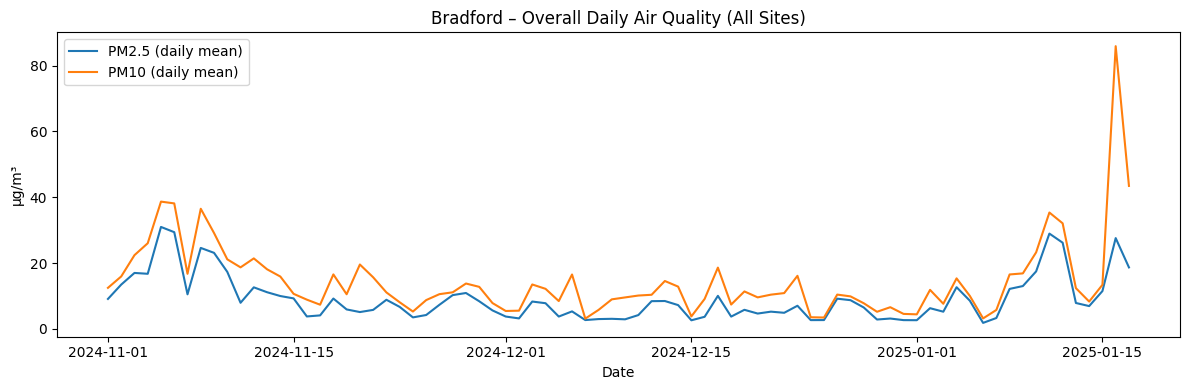

In [26]:
# Overall daily means across sites
overall_daily = (
    daily.groupby("date", as_index=False)
         .agg(
             pm10_mean=("pm10_mean", "mean"),
             pm25_mean=("pm25_mean", "mean"),
         )
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(overall_daily["date"], overall_daily["pm25_mean"], label="PM2.5 (daily mean)")
ax.plot(overall_daily["date"], overall_daily["pm10_mean"], label="PM10 (daily mean)")
ax.set_title("Bradford – Overall Daily Air Quality (All Sites)")
ax.set_xlabel("Date")
ax.set_ylabel("µg/m³")
ax.legend()
plt.tight_layout()
plt.show()

What this shows: the winter pattern, peaks, and general level across Bradford.

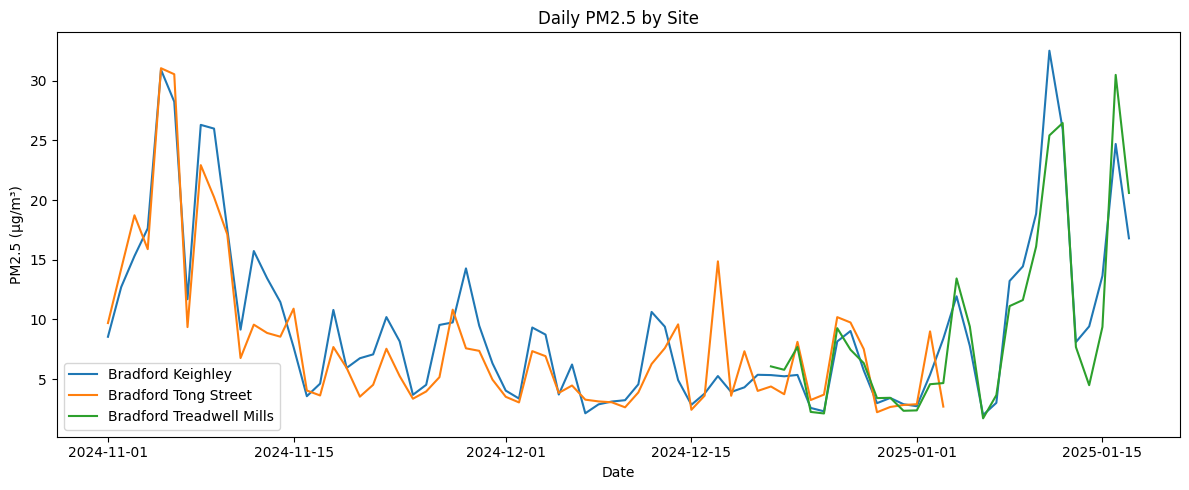

In [27]:
# Daily PM2.5 trend by site
fig, ax = plt.subplots(figsize=(12, 5))

for site, g in daily.groupby("site"):
    ax.plot(g["date"], g["pm25_mean"], label=site)

ax.set_title("Daily PM2.5 by Site")
ax.set_xlabel("Date")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend()
plt.tight_layout()
plt.show()

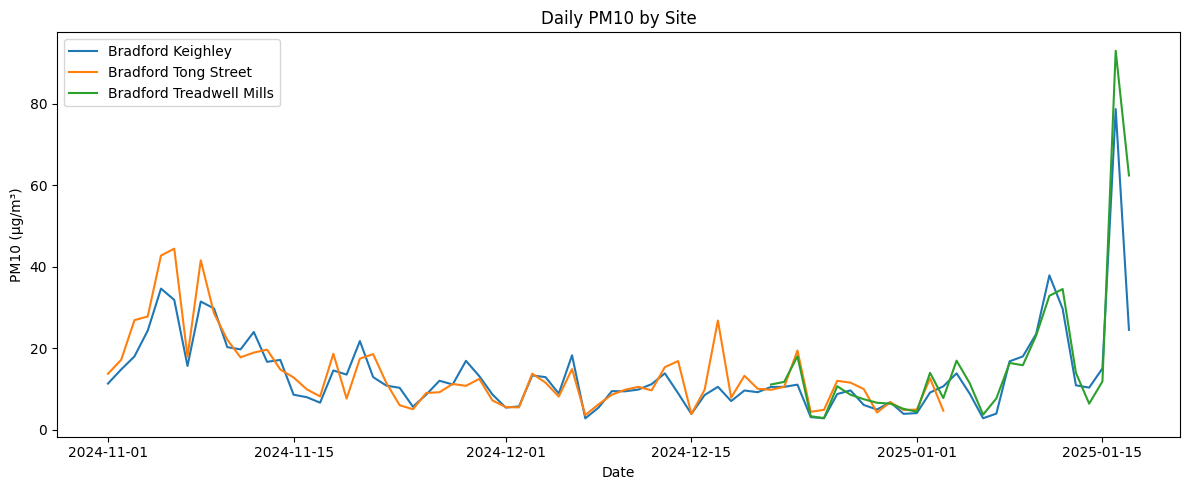

In [28]:
# Daily PM10 trend by site
fig, ax = plt.subplots(figsize=(12, 5))

for site, g in daily.groupby("site"):
    ax.plot(g["date"], g["pm10_mean"], label=site)

ax.set_title("Daily PM10 by Site")
ax.set_xlabel("Date")
ax.set_ylabel("PM10 (µg/m³)")
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
# --- Helper: consistent layout + visible axis lines ---
def polish(fig, title, y_title="µg/m³"):
    fig.update_layout(
        title=title,
        hovermode="x unified",
        template="plotly_white",
        legend_title_text="",
        margin=dict(l=50, r=20, t=60, b=50),
        height=420,
    )

    # Force visible axis border lines (x/y axis "spines")
    fig.update_xaxes(
        title_text="Date",
        showline=True,
        linewidth=1,
        linecolor="black",
        mirror=True,     # show lines on top as well
        ticks="outside"
    )
    fig.update_yaxes(
        title_text=y_title,
        showline=True,
        linewidth=1,
        linecolor="black",
        mirror=True,     # show lines on right as well
        ticks="outside"
    )
    return fig


def show_and_save(fig, html_name):
    fig.show()  # <-- show in notebook
    pio.write_html(fig, out_dir / html_name, include_plotlyjs="cdn")


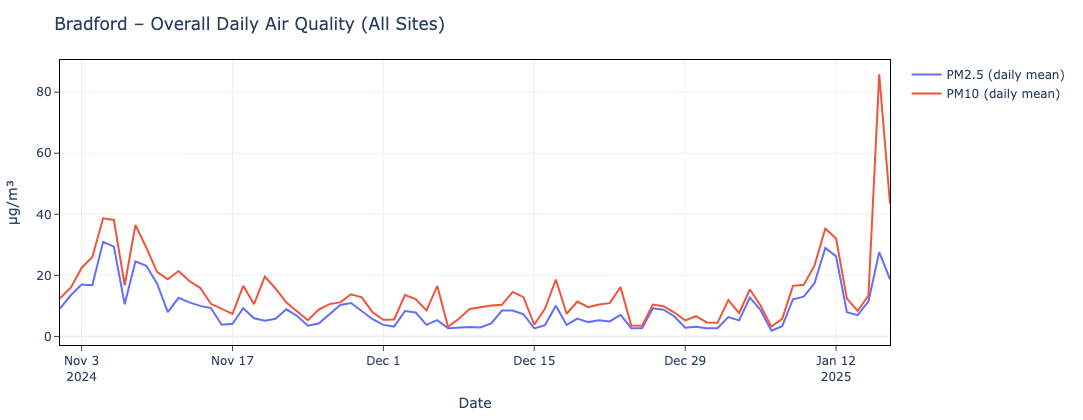

In [30]:
# -----------------------------
# 1) Overall daily trend (all sites)
# -----------------------------
overall_daily = (
    daily.groupby("date", as_index=False)
         .agg(pm10_mean=("pm10_mean", "mean"),
              pm25_mean=("pm25_mean", "mean"))
)

overall_long = overall_daily.melt(
    id_vars="date",
    value_vars=["pm25_mean", "pm10_mean"],
    var_name="pollutant",
    value_name="value"
)

overall_long["pollutant"] = overall_long["pollutant"].map({
    "pm25_mean": "PM2.5 (daily mean)",
    "pm10_mean": "PM10 (daily mean)"
})

fig1 = px.line(overall_long, x="date", y="value", color="pollutant")
fig1 = polish(fig1, "Bradford – Overall Daily Air Quality (All Sites)")

show_and_save(fig1, "fig1_overall_daily_trend.html")


Overall daily air quality (all sites)
	•	Air quality shows clear temporal variability, with higher PM levels in early November and mid-January.
	•	PM10 exhibits sharper spikes than PM2.5, suggesting short-term local or episodic sources.
	•	PM2.5 follows a smoother pattern, indicating broader regional influences.

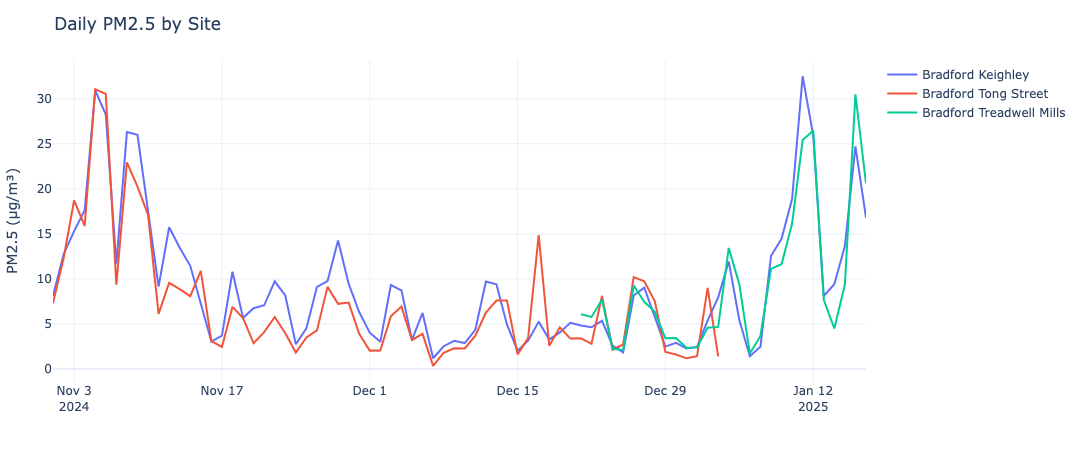

In [52]:
# 2) Daily PM2.5 trend by site
pm25_site = daily[["site", "date", "pm25_mean"]].copy()
pm25_site["date"] = pd.to_datetime(pm25_site["date"])

fig2 = px.line(pm25_site, x="date", y="pm25_mean", color="site")
fig2 = polish(fig2, "Daily PM2.5 by Site", y_title="PM2.5 (µg/m³)")
fig2.show()
pio.write_html(fig2, out_dir / "fig2_pm25_by_site.html", include_plotlyjs="cdn")

Daily PM2.5 by site
	•	PM2.5 levels are more consistent across sites, with fewer extreme spikes than PM10.
	•	Keighley and Treadwell Mills show higher peaks than Tong Street toward the end of the period.
	•	This suggests regional background pollution with some site-specific enhancement.

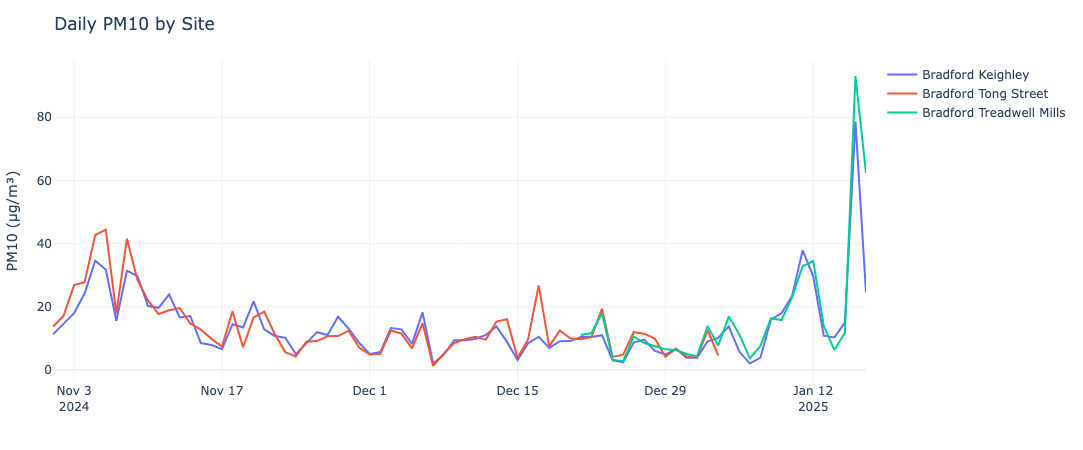

In [54]:
# 3) Daily PM10 trend by site
pm10_site = daily[["site", "date", "pm10_mean"]].copy()
pm10_site["date"] = pd.to_datetime(pm10_site["date"])

fig3 = px.line(pm10_site, x="date", y="pm10_mean", color="site")
fig3 = polish(fig3, "Daily PM10 by Site", y_title="PM10 (µg/m³)")
fig3.show()
pio.write_html(fig3, out_dir / "fig3_pm10_by_site.html", include_plotlyjs="cdn")


Daily PM10 by site
	•	Treadwell Mills records the highest PM10 peaks, particularly during the January episode.
	•	Keighley and Tong Street broadly track similar trends, but with lower peak magnitudes.
	•	Spikes are synchronous across sites, pointing to shared events with local amplification.

Across the winter period, PM10 shows sharper, site-specific spikes, while PM2.5 is more uniform across Bradford, indicating a mix of localised events and wider regional pollution influences.

## Analysis — Site ranking

In [55]:
# Create the site-level summary table
site_rank = (
    daily.groupby("site", as_index=False)
         .agg(
             avg_pm25=("pm25_mean", "mean"),
             avg_pm10=("pm10_mean", "mean"),
             days_observed=("date", "nunique")
         )
)

display(site_rank)

,site,avg_pm25,avg_pm10,days_observed
0,Bradford Keighley,9.260507,13.618965,78
1,Bradford Tong Street,7.042159,13.228413,78
2,Bradford Treadwell Mills,9.266175,16.691311,78


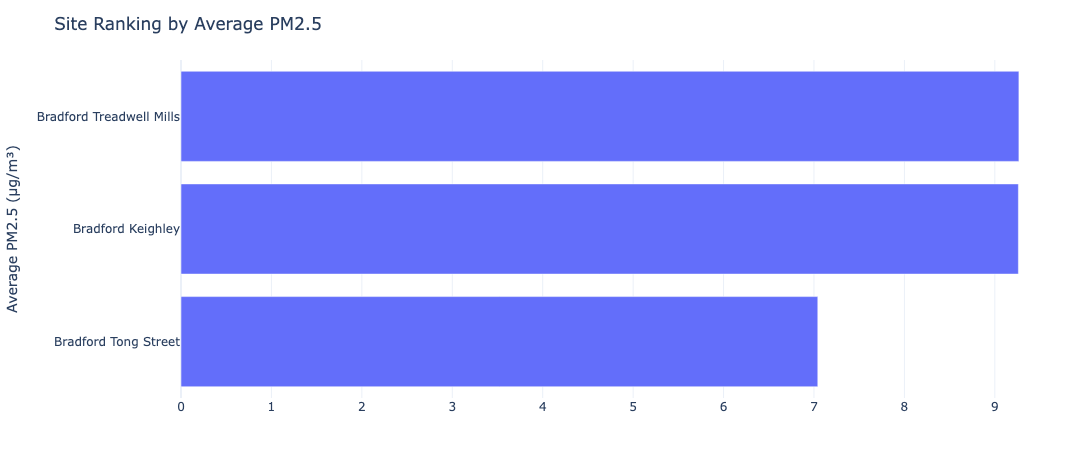

In [56]:
# Plot: Site ranking by average PM2.5
fig4 = px.bar(
    site_rank.sort_values("avg_pm25", ascending=True),
    x="avg_pm25",
    y="site",
    orientation="h"
)

fig4 = polish(fig4, "Site Ranking by Average PM2.5", y_title="Average PM2.5 (µg/m³)")
fig4.show()
pio.write_html(fig4, out_dir / "fig4_site_ranking_pm25.html", include_plotlyjs="cdn")

This shows which locations consistently experience higher fine-particle pollution across the period.

Site ranking – PM2.5
	•	Treadwell Mills and Keighley show similarly high PM2.5, both above Tong Street.
	•	Tong Street consistently records lower PM2.5, indicating comparatively better air quality.
	•	PM2.5 appears more regionally influenced, with smaller differences between the highest sites.

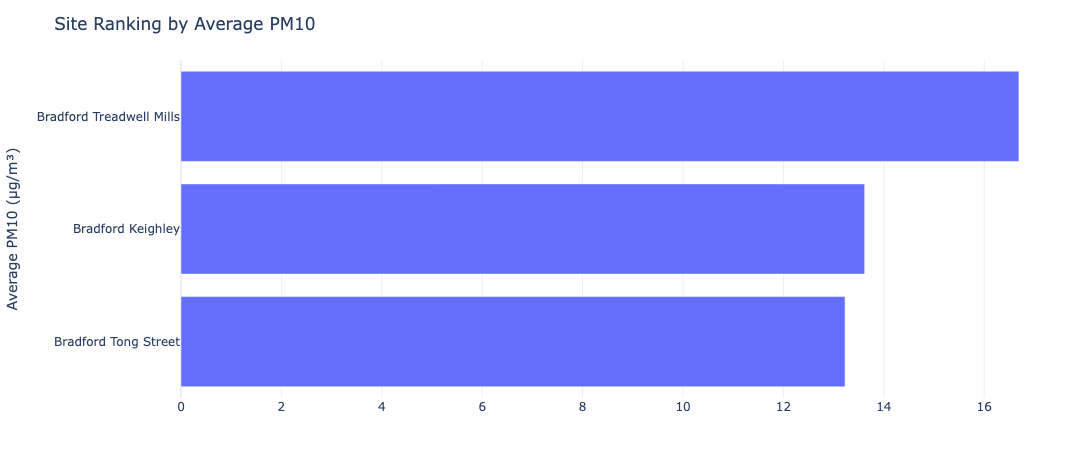

In [57]:
# Plot: Site ranking by average PM10
fig5 = px.bar(
    site_rank.sort_values("avg_pm10", ascending=True),
    x="avg_pm10",
    y="site",
    orientation="h"
)

fig5 = polish(fig5, "Site Ranking by Average PM10", y_title="Average PM10 (µg/m³)")
fig5.show()
pio.write_html(fig5, out_dir / "fig5_site_ranking_pm10.html", include_plotlyjs="cdn")

Site ranking – PM10
	•	Treadwell Mills has the highest average PM10, indicating consistently higher coarse particle levels.
	•	Keighley is intermediate, while Tong Street records the lowest averages.
	•	This suggests localised sources rather than uniform city-wide exposure.

One-liner to say aloud:

“We see clear spatial differences, with Treadwell Mills consistently highest, Tong Street lowest, and Keighley in between, suggesting targeted local interventions rather than a one-size-fits-all approach.”